# TSA — Week 4 Python Lab: Stationarity Investigation
## Phnom Penh monthly precipitation (2015–2025)

**Student:** Heng Hour  |  **Group:** 9  |  **GitHub repository:** https://github.com/hengXiaoHour/tsa-course

**Main question:** Does the statistical behaviour of the series appear stable through time?

**Connection:** Week 2 made time and seasonal plots using `long['date']` and `long['precipitation']`. Week 3 explored lags and autocorrelation. In Week 4, reuse both ideas to investigate stationarity.

**Learning focus:** inspect stability of level and variation, compare earlier/later windows, revisit the ACF, contrast white noise and a stationary dependent series with a random walk, and write an evidence-based judgement.

**Scope:** This is a visual and descriptive investigation, **not a formal stationarity test**. ADF, KPSS, PACF, differencing and ARIMA are not required here.

**Textbook basis:** Shumway & Stoffer, *Time Series Analysis and Its Applications*, 5th ed., §§1.3–1.5; Hyndman & Athanasopoulos, *Forecasting: Principles and Practice*, §2.8 (ACF). Python demonstrations and the local dataset are classroom adaptations.

**Data-source caution:** The included table is the same exact numeric table used in Week 2. The available copy does not contain the complete NASA POWER metadata or a confirmed unit. Plots therefore say **source units (confirm mm)**; do not claim gauge measurements or verified physical units without consulting the original download metadata.

## Before you start — use Week 2 names

Across these labs we keep **`long`** as the working DataFrame, **`date`** as the time index column, and **`precipitation`** as the target column. No `df`/`precip` renaming is needed.

This notebook can run independently in Google Colab. The next cell creates `long` using **the same source table and wide-to-long transformation as Week 2**, but only when `long` is not already present. If you run Week 4 after Week 2–3 in the same runtime, your existing `long` is reused.

If you are using the **Week 2 exported CSV** in a new runtime instead of the embedded source table, you can load it with `long = pd.read_csv('phnom_penh_monthly_precipitation_2015_2025_long.csv')` after uploading it to Colab; then skip the embedded-data creation. The validation cell below checks either route.


In [1]:
# Prepare the Week 2 `long` DataFrame when this notebook is opened on its own.
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf

# This is exactly the table used in the Week 2 notebook; ANN is not an extra month.
RAW_CSV = 'YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,ANN\n2015,3.26,6.85,6.79,86.97,46.84,85.88,41.22,288.64,133.08,134.41,70.89,13.06,917.89\n2016,26.66,4.83,6.41,7.81,117.14,43.76,25.41,23.91,138.2,166.56,137.19,33.45,731.33\n2017,18.64,16.04,14.73,29.46,123.78,62.85,140.62,175,213.37,87.4,93.56,41.91,1017.36\n2018,75.61,7.22,80.34,94.97,177.46,338.51,205.87,41.17,224.33,155.88,20.71,39.95,1462.02\n2019,19.07,2.88,25.55,59.37,236.16,392.3,223.72,263.68,263.18,93.11,29.63,0.34,1608.99\n2020,26.58,2.14,34.14,146.86,92.3,703.62,166.68,174.17,280.88,496.85,98.6,67.73,2290.55\n2021,11.54,10.8,10.14,111.31,243.46,121.11,299.33,261.06,329.28,240.56,213,31.5,1883.09\n2022,5.36,56.69,128.22,115.23,205.65,262.05,439.12,276.57,250.76,185.5,130.42,26.53,2082.1\n2023,30.18,6.23,1.08,22.04,108.3,154.58,177.06,158.74,315.42,266.52,131.32,30.82,1402.29\n2024,1.75,0.8,13.03,2.15,146.8,212.52,271.85,147.87,207.61,233.95,50.78,20.45,1309.56\n2025,1.02,19.62,44.45,48.73,46.49,69.32,36.31,291.32,146,172.7,91.83,16.72,984.51'

if 'long' in globals() and isinstance(long, pd.DataFrame):
    print('Using the existing Week 2–3 DataFrame: long')
else:
    raw = pd.read_csv(io.StringIO(RAW_CSV))
    MONTHS = ['JAN','FEB','MAR','APR','MAY','JUN','JUL','AUG','SEP','OCT','NOV','DEC']
    long = raw.melt(id_vars=['YEAR'], value_vars=MONTHS,
                    var_name='month_name', value_name='precipitation')
    long['month'] = long['month_name'].map({name:i for i,name in enumerate(MONTHS,1)})
    long['date'] = pd.to_datetime(dict(year=long['YEAR'],month=long['month'],day=1))
    long = long[['date','YEAR','month','month_name','precipitation']].sort_values('date').reset_index(drop=True)
    long['precipitation'] = pd.to_numeric(long['precipitation'],errors='coerce')
    long.loc[long['precipitation'] <= -900, 'precipitation'] = np.nan
    print('Recreated Week 2 `long` from the same embedded source data.')

display(long.head())


Recreated Week 2 `long` from the same embedded source data.


,date,YEAR,month,month_name,precipitation
0,2015-01-01,2015,1,JAN,3.26
1,2015-02-01,2015,2,FEB,6.85
2,2015-03-01,2015,3,MAR,6.79
3,2015-04-01,2015,4,APR,86.97
4,2015-05-01,2015,5,MAY,46.84


In [2]:
# Week 4 — imports (already loaded above)
# Keep `long['date']` and `long['precipitation']` from Week 2.


## 1. Predict first

Before running the stationarity analysis, answer:

**Do you think the rainfall series is:**
- Stationary-looking
- Not stationary-looking
- Unsure

Explain your prediction in **1–2 sentences**.

**My prediction:** **Not stationary-looking.** From Week 2 the seasonal cycle is very strong (February averages 12.19 while September averages 227.46), so the typical level depends on the calendar month, which already violates the constant-mean requirement.

In [3]:
# Check the Week 2–3 dataframe without silently removing months.
required = {'date', 'precipitation'}
missing_columns = required - set(long.columns)
if missing_columns:
    raise ValueError(f'Missing columns: {sorted(missing_columns)}. Use the Week 2 `long` dataframe.')

long = long.copy()
long['date'] = pd.to_datetime(long['date'], errors='coerce')
long['precipitation'] = pd.to_numeric(long['precipitation'], errors='coerce')
long = long.sort_values('date').reset_index(drop=True)

if long['date'].isna().any():
    raise ValueError('Invalid dates found. Investigate before analysis.')
if long['date'].duplicated().any():
    raise ValueError('Duplicate months found. Investigate before analysis.')
if long['precipitation'].isna().any():
    raise ValueError('Missing precipitation values found. Investigate; do not silently drop months.')

expected = pd.date_range(long['date'].min(), long['date'].max(), freq='MS')
missing_months = expected.difference(pd.DatetimeIndex(long['date']))
if len(missing_months):
    raise ValueError(f'Missing monthly dates: {list(missing_months.strftime("%Y-%m"))}')
if len(long) != len(expected):
    raise ValueError('Expected one observation for each month.')

print('Observations:', len(long))
print('Start:',long['date'].min().date(),'End:',long['date'].max().date())
print('Missing values:',long['precipitation'].isna().sum(), '| Missing months:', len(missing_months))
display(long[['date','precipitation']].head())


Observations: 132
Start: 2015-01-01 End: 2025-12-01
Missing values: 0 | Missing months: 0


,date,precipitation
0,2015-01-01,3.26
1,2015-02-01,6.85
2,2015-03-01,6.79
3,2015-04-01,86.97
4,2015-05-01,46.84


## 2. Inspect the full time plot

Look for visual evidence:

1. Does the typical level appear similar through time?
2. Does the variability appear similar through time?
3. Is there a clear long-term trend?
4. Is there a persistent change or shift?
5. What seasonal behaviour do you notice?

Remember: a time plot provides **visual evidence**, not formal proof of stationarity.


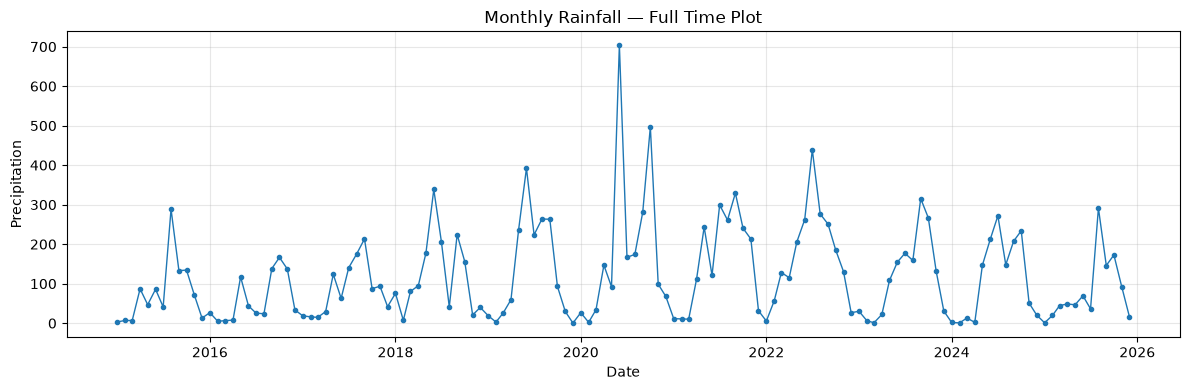

In [4]:
plt.figure(figsize=(12, 4))

plt.plot(
    long['date'],
    long['precipitation'],
    marker='o',
    markersize=3,
    linewidth=1
)

plt.title('Monthly Rainfall — Full Time Plot')
plt.xlabel('Date')
plt.ylabel('Precipitation')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### My observations

1. **The typical level is not stable through time.** Every year repeats the same dry-to-wet swing, and yearly means range from 60.9 (2016) to 190.9 (2020); June 2020 reaches 703.62, far above any other month.
2. **Variability stays in the same order of magnitude but is not constant.** The early window has sd 68.70 versus 96.22 late, and the 2020 spike stretches the vertical scale well beyond the early years.
3. **No steady long-term trend, but clear seasonal behaviour.** Annual totals fit a slope of +48.3 per year yet year explains only about 10% of their variation (r = 0.318), with totals rising to 2020 then falling back to 984.51 in 2025; the repeating pattern is dry January–March, wet June–October with a September peak.

## 3. Compare two windows in time

We compare the **first 36 observations** and the **last 36 observations**.

For monthly data, this is approximately three years in each window.

Ask:
- Is the typical level similar?
- Is the variability similar?
- Does the overall behaviour look similar?


In [5]:
window_size = 36

if len(long) < window_size * 2:
    raise ValueError(
        f"This activity needs at least {window_size * 2} observations. "
        f"Current dataset has {len(long)}."
    )

early = long.iloc[:window_size].copy()
late = long.iloc[-window_size:].copy()

print("Earlier period:")
print(early['date'].min(), "to", early['date'].max())

print("\nLater period:")
print(late['date'].min(), "to", late['date'].max())


Earlier period:
2015-01-01 00:00:00 to 2017-12-01 00:00:00

Later period:
2023-01-01 00:00:00 to 2025-12-01 00:00:00


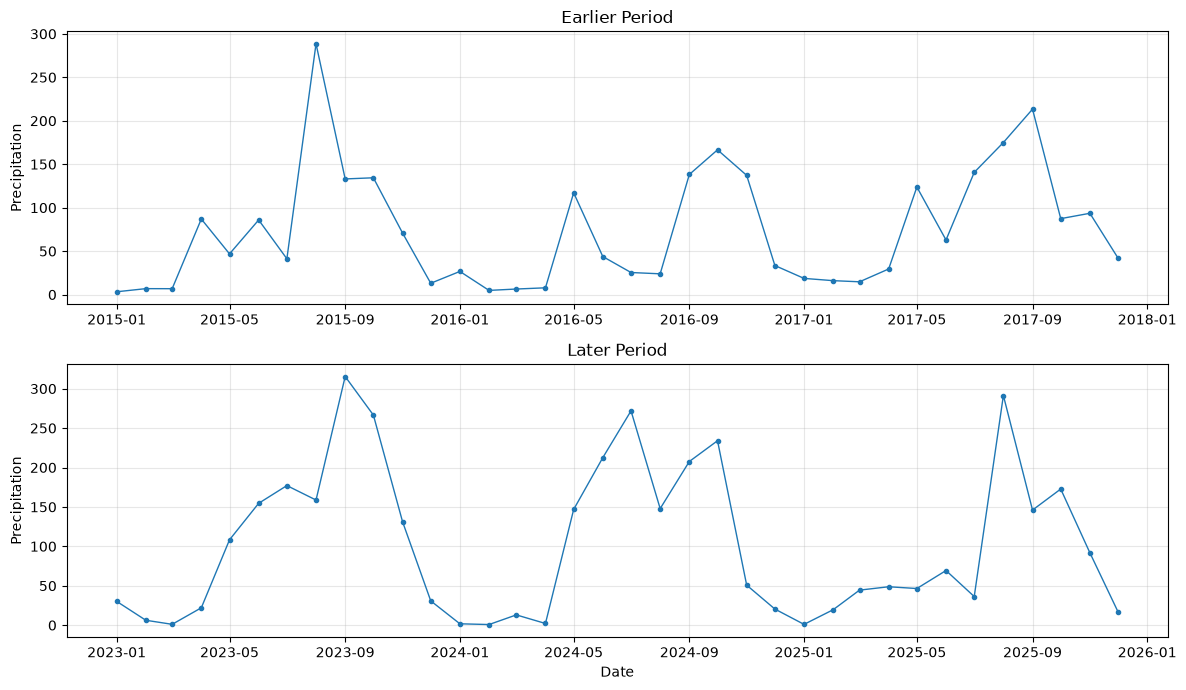

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7))

axes[0].plot(
    early['date'],
    early['precipitation'],
    marker='o',
    markersize=3,
    linewidth=1
)
axes[0].set_title('Earlier Period')
axes[0].set_ylabel('Precipitation')
axes[0].grid(alpha=0.3)

axes[1].plot(
    late['date'],
    late['precipitation'],
    marker='o',
    markersize=3,
    linewidth=1
)
axes[1].set_title('Later Period')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Precipitation')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [7]:
# Descriptive evidence — NOT a formal stationarity test

comparison = pd.DataFrame({
    'Period': ['Earlier', 'Later'],
    'Mean': [
        early['precipitation'].mean(),
        late['precipitation'].mean()
    ],
    'Standard deviation': [
        early['precipitation'].std(),
        late['precipitation'].std()
    ],
    'Minimum': [
        early['precipitation'].min(),
        late['precipitation'].min()
    ],
    'Maximum': [
        early['precipitation'].max(),
        late['precipitation'].max()
    ]
})

display(comparison.round(2))


,Period,Mean,Standard deviation,Minimum,Maximum
0,Earlier,74.07,68.70,3.26,288.64
1,Later,102.68,96.22,0.80,315.42


### Compare the two periods

| Evidence | Earlier period | Later period | Similar? |
|---|---|---|---|
| Typical level | Mean 74.07 (Jan 2015–Dec 2017) | Mean 102.68 (Jan 2023–Dec 2025) | No — later sits about 28.6 higher |
| Variability | sd 68.70, range 3.26–288.64 | sd 96.22, range 0.80–315.42 | No — later spreads wider |
| Overall behaviour | Dry start, wet middle, autumn peak, each year | Same seasonal shape, each year | Broadly similar shape, different level |

**Question:** Do these two periods appear to follow reasonably similar statistical behaviour?

**My answer:** No. The seasonal shape repeats in both windows, but the typical level (74.07 against 102.68) and the spread (sd 68.70 against 96.22) both moved, so the statistical behaviour is not reasonably similar.

## 4. Revisit the Week 3 ACF

Week 3 asked:

> **Is the present related to the past?**

Week 4 asks:

> **Does the dependence behaviour appear reasonably stable through time?**


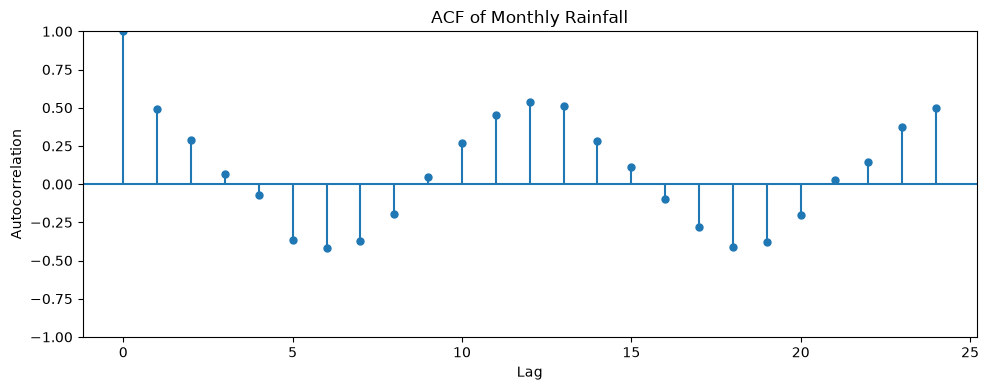

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))

plot_acf(
    long['precipitation'],
    lags=min(24, len(long) // 2 - 1),
    alpha=None,   # keep confidence bands out at this stage
    ax=ax
)

ax.set_title('ACF of Monthly Rainfall')
ax.set_xlabel('Lag')
ax.set_ylabel('Autocorrelation')

plt.tight_layout()
plt.show()


### Full-series ACF questions

1. What happens at lag 1?
2. What happens around lag 12 (one year for monthly data)?
3. What does the ACF suggest about dependence across time?
4. Does this ACF by itself prove stationarity? Why or why not?

**My interpretation:** Lag 1 is clearly positive (0.492 on overlapping pairs), so consecutive months carry information about each other. Lag 12 is the strongest positive autocorrelation (about 0.54 on the plot, 0.567 on pairs) with the pattern repeating at lag 24, so the series shows real dependence, including an annual cycle. This ACF by itself does **not** prove stationarity: the lecture's stationary dependent example also has nonzero ACF, so dependence and stability are separate questions — the ACF answers whether the past matters, not whether the behaviour stays the same.

## 5. Compare ACF: earlier vs later period

This is a practical visual comparison.

Different sample ACF values are expected. We are looking for **broadly similar or clearly different dependence behaviour**, not exact equality.


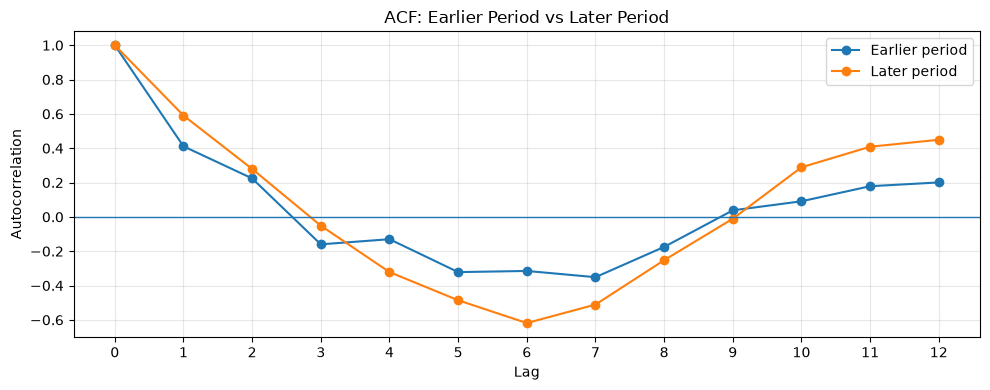

In [9]:
max_lag = min(12, len(early) // 2 - 1, len(late) // 2 - 1)

acf_early = acf(
    early['precipitation'],
    nlags=max_lag,
    fft=False
)

acf_late = acf(
    late['precipitation'],
    nlags=max_lag,
    fft=False
)

lags = np.arange(max_lag + 1)

plt.figure(figsize=(10, 4))

plt.plot(lags, acf_early, marker='o', label='Earlier period')
plt.plot(lags, acf_late, marker='o', label='Later period')

plt.axhline(0, linewidth=1)
plt.title('ACF: Earlier Period vs Later Period')
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.xticks(lags)
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


### Dependence through time

1. Are the two ACF patterns reasonably similar?
2. What happens around lag 1?
3. What happens around lag 12?
4. Does the dependence behaviour appear similar in both periods?

**My interpretation:** Yes, broadly similar. Both windows show positive lag 1 (0.41 early, 0.59 late), a mid-lag dip into negative values, and a rise at lag 12 (0.20 early, 0.45 late). The magnitudes differ, which is expected with only 36 observations per window and a wider late spread, but the shape matches — so the dependence behaviour looks reasonably similar even though the level does not.

# Activity — Stationarity Detective

Before returning to the rainfall data, compare three known examples.

You will see:

- **Series A**
- **Series B**
- **Series C**

Do **not** reveal their identities until after making your judgement.


In [10]:
np.random.seed(42)

n = 150

# A: white noise
series_A = np.random.normal(0, 1, n)

# B: stationary dependent process
# A simple three-point moving-average-style construction.
noise = np.random.normal(0, 1, n + 2)
series_B = (
    noise[:-2] +
    noise[1:-1] +
    noise[2:]
) / 3

# C: random walk
series_C = np.cumsum(
    np.random.normal(0, 1, n)
)

series_dict = {
    'Series A': series_A,
    'Series B': series_B,
    'Series C': series_C
}


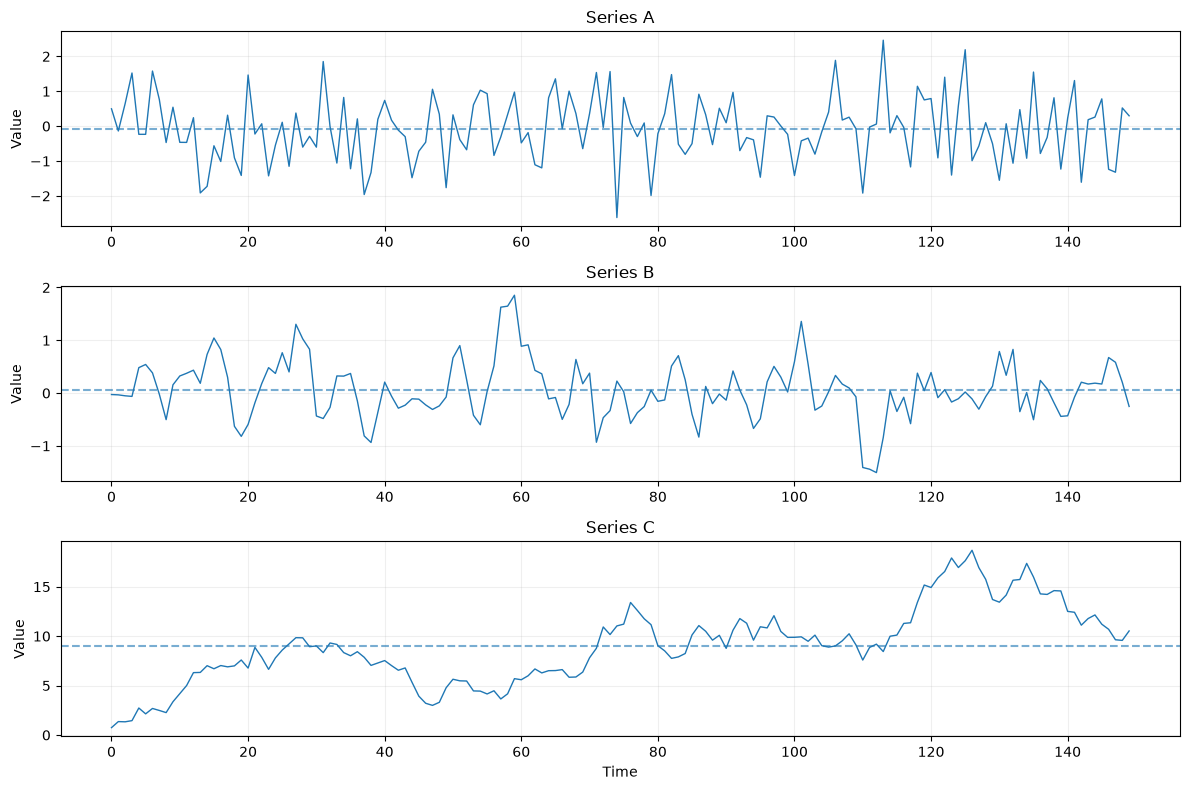

In [11]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8))

for ax, (name, values) in zip(axes, series_dict.items()):
    ax.plot(values, linewidth=1)
    ax.axhline(values.mean(), linestyle='--', alpha=0.6)
    ax.set_title(name)
    ax.set_ylabel('Value')
    ax.grid(alpha=0.2)

axes[-1].set_xlabel('Time')

plt.tight_layout()
plt.show()


## 6. Decide before seeing the ACF

For each series choose:

**Stationary-looking / Not stationary-looking / Unsure**

### Series A
**Decision:** Stationary-looking

**Evidence:** Fluctuates around a stable mean of -0.08 (sd 0.94), with the first half averaging -0.115 and the second -0.050 — no drift, no widening.

### Series B
**Decision:** Stationary-looking

**Evidence:** Stable mean of 0.06 with halves at 0.163 and -0.034, but visibly smoother short wiggles than A, so nearby values share information (dependence, still stationary).

### Series C
**Decision:** Not stationary-looking

**Evidence:** Wanders from 0.75 up to 18.69 instead of fluctuating around one level; the first half averages 6.16 but the second 11.82 — the level moves through time.

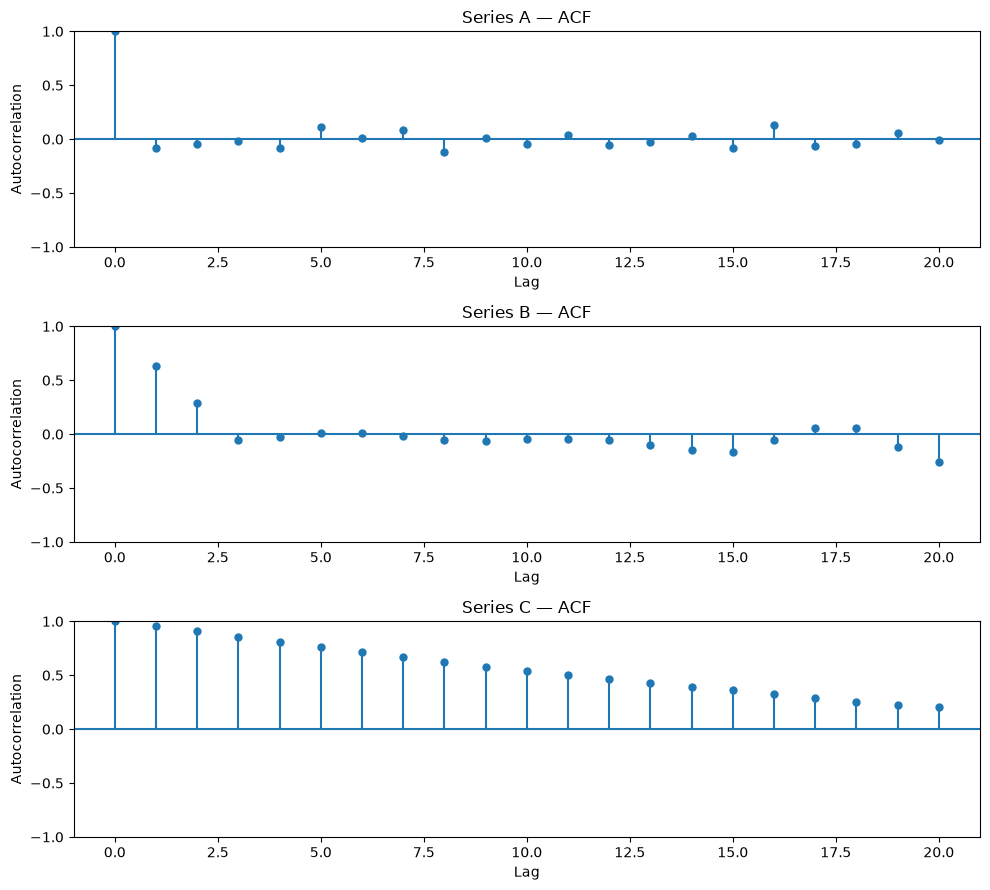

In [12]:
fig, axes = plt.subplots(3, 1, figsize=(10, 9))

for ax, (name, values) in zip(axes, series_dict.items()):
    plot_acf(
        values,
        lags=20,
        alpha=None,
        ax=ax
    )

    ax.set_title(f'{name} — ACF')
    ax.set_xlabel('Lag')
    ax.set_ylabel('Autocorrelation')

plt.tight_layout()
plt.show()


## 7. Did the ACF change your decision?

For each series:

- What did the time plot suggest?
- What did the ACF add?
- Did you change your original decision?

### Series A
The jagged time plot around a flat mean suggested stationary independence; the ACF stays near zero at all lags (largest magnitude 0.13), confirming it. No change: stationary white noise.

### Series B
The smooth wiggles suggested stationary dependence; the ACF confirms it with 0.635 at lag 1 decaying to 0.292 at lag 2. No change — and this is the key lesson: **stationary does not mean independent**.

### Series C
The wandering level suggested non-stationarity; the ACF confirms persistence with 0.954 at lag 1 decaying only to 0.855 at lag 3. No change: random walk, not stationary.

In [13]:
print("REVEAL")
print("------")
print("Series A = White noise")
print("Series B = Stationary dependent process")
print("Series C = Random walk")


REVEAL
------
Series A = White noise
Series B = Stationary dependent process
Series C = Random walk


### What should we learn?

**Series A — White noise**
- Stationary.
- Little/no autocorrelation at non-zero lags.

**Series B — Stationary dependent process**
- Stationary.
- Has autocorrelation.
- **Stationary does not mean independent.**

**Series C — Random walk**
- Not stationary.
- Its level wanders through time rather than remaining around one stable level.


# 8. Final Evidence Table — Your Rainfall Series

Complete the table using evidence from your analysis.


In [14]:
evidence = pd.DataFrame({
    'Question': [
        'Does the typical level appear stable?',
        'Does variability appear reasonably stable?',
        'Is there a clear trend?',
        'Is there a persistent level shift?',
        'Do earlier and later periods look similar?',
        'Does the dependence / ACF look reasonably similar?'
    ],
    'My evidence': [
        'No — FEB mean 12.19 vs SEP mean 227.46; yearly means 60.9 to 190.9.',
        'Roughly — same order of magnitude, but early sd 68.70 vs late sd 96.22.',
        'No steady trend — annual slope +48.3/yr yet r = 0.318 (year explains ~10%).',
        'No single permanent step, but the mean moves: early 74.07 vs late 102.68.',
        'Same seasonal shape, different level and spread — not reasonably similar.',
        'Yes, broadly — both windows show lag-1 positive with a lag-12 rise.'
    ]
})

display(evidence)

,Question,My evidence
0,Does the typical level appear stable?,No — FEB mean 12.19 vs SEP mean 227.46; yearly...
1,Does variability appear reasonably stable?,"Roughly — same order of magnitude, but early s..."
2,Is there a clear trend?,No steady trend — annual slope +48.3/yr yet r ...
3,Is there a persistent level shift?,"No single permanent step, but the mean moves: ..."
4,Do earlier and later periods look similar?,"Same seasonal shape, different level and sprea..."
5,Does the dependence / ACF look reasonably simi...,"Yes, broadly — both windows show lag-1 positiv..."


# 9. Week 4 Final Conclusion

### My judgement

I think this series is:

- [ ] Stationary-looking
- [x] Not stationary-looking
- [ ] Unsure

### Evidence 1

The typical level changes with the season: February averages 12.19 while September averages 227.46 (a range of 215.3), so the mean depends on the calendar month rather than staying constant.

### Evidence 2

The level also shifts between periods: the first 36 months average 74.07 against 102.68 for the last 36, and yearly means range from 60.9 (2016) to 190.9 (2020).

### Optional additional evidence

Dependence itself looks reasonably stable — both windows show positive lag 1 and a lag-12 rise — and the full-series ACF confirms real dependence with lag 12 strongest (about 0.54 on the plot, 0.567 on pairs). But stable dependence cannot rescue an unstable mean, and a nonzero ACF alone never proves stationarity anyway.

### Limitation

This conclusion is based on visual inspection, descriptive evidence, and the ACF. It does **not formally prove stationarity**.

**Seasonality note:** A repeating monthly seasonal mean can violate stationarity of the raw series. The full-series ACF alone cannot establish that the dependence structure stays unchanged over time.

## Submission check

Before submitting, make sure your Week 4 section contains:

- [ ] Prediction before analysis
- [ ] Full time plot
- [ ] Earlier vs later period comparison
- [ ] Descriptive comparison
- [ ] Full-series ACF
- [ ] Earlier vs later ACF comparison
- [ ] Stationarity Detective activity
- [ ] Final evidence table
- [ ] Final evidence-based conclusion

**Practical outcome:** Add this Week 4 investigation to your individual TSA Colab portfolio.
